# Proof of Concept with OpenCV 01

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import math
from scipy.signal import correlate

In [14]:
def show_image(image, title=None):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.show()


def show_images(images, titles=None, max_cols=3):
    n_images = len(images)
    n_rows = math.ceil(n_images / max_cols)
    plt.figure(figsize=(5 * max_cols, 4 * n_rows))

    for i, img in enumerate(images):
        plt.subplot(n_rows, max_cols, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if titles and i < len(titles):
            plt.title(titles[i])

    plt.tight_layout()
    plt.show()

## Load Image

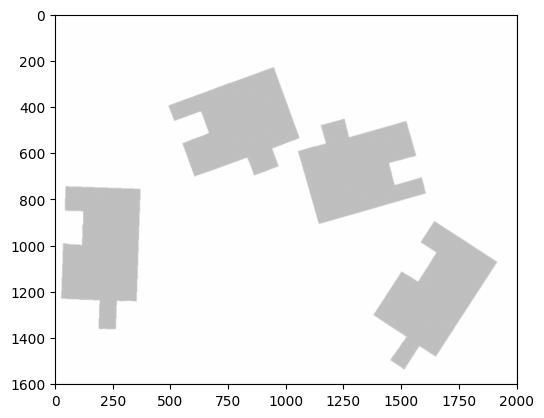

In [15]:
image = cv2.imread("../assets/puzzle_images/simulator_01.png")
show_image(image)

## Object Detection

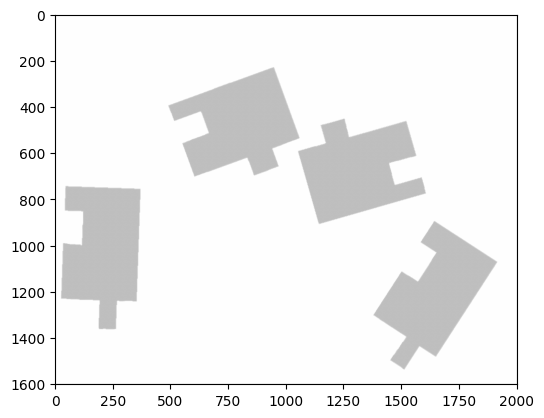

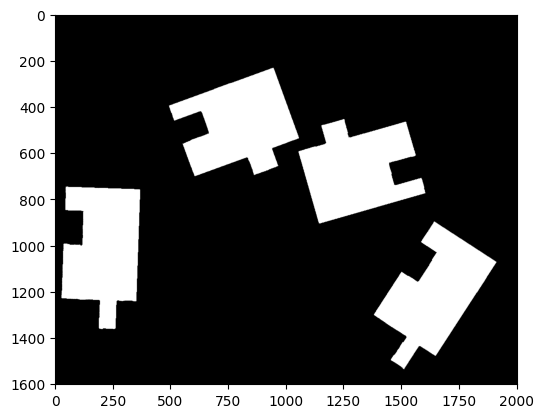

In [16]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
show_image(gray_image)

_, thresh = cv2.threshold(gray_image, 200, 255, cv2.THRESH_BINARY_INV)
show_image(thresh)

In [17]:
def draw_bounding_boxes(image, boxes):
    image = np.copy(image)

    for box in boxes:
        x1, y1, x2, y2 = [int(coord) for coord in box]
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 10)

    return image

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

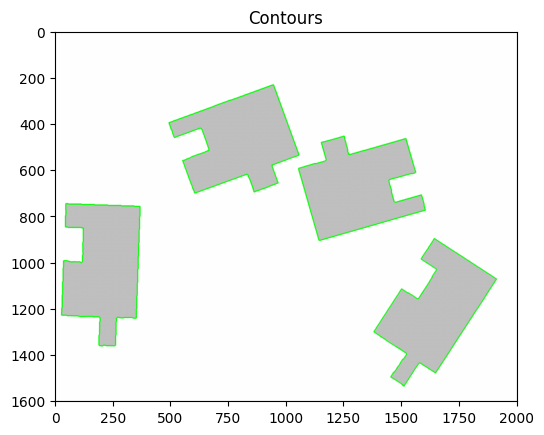

In [18]:
pieces_image = image.copy()
pieces_image = cv2.drawContours(pieces_image, contours, -1, (0, 255, 0), 3)

show_image(pieces_image, "Contours")

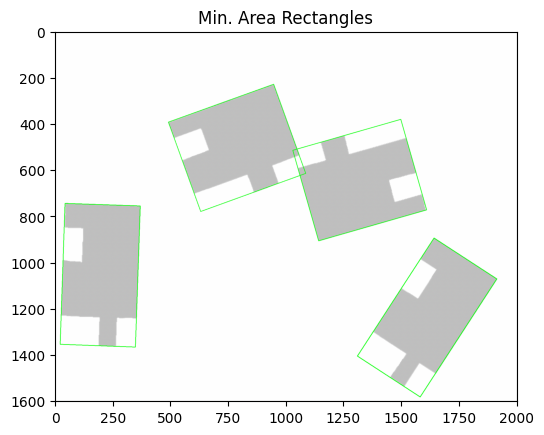

In [19]:
pieces_image = image.copy()
pieces = []

for i, c in enumerate(contours):
    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect).astype(np.float32)

    # Compute width and height from the box
    w = int(np.linalg.norm(box[1] - box[0]))
    h = int(np.linalg.norm(box[2] - box[1]))

    # Define the destination points for a straight rectangle
    dst_pts = np.array([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ], dtype=np.float32)

    # Perspective transform matrix
    M = cv2.getPerspectiveTransform(box, dst_pts)

    # Warp (crop) the rotated piece
    cropped = cv2.warpPerspective(thresh, M, (w, h))
    pieces.append(cropped)

    # Draw contour box on visualization image
    cv2.drawContours(pieces_image, [box.astype(int)], 0, (0, 255, 0), 2)

show_image(pieces_image, "Min. Area Rectangles")

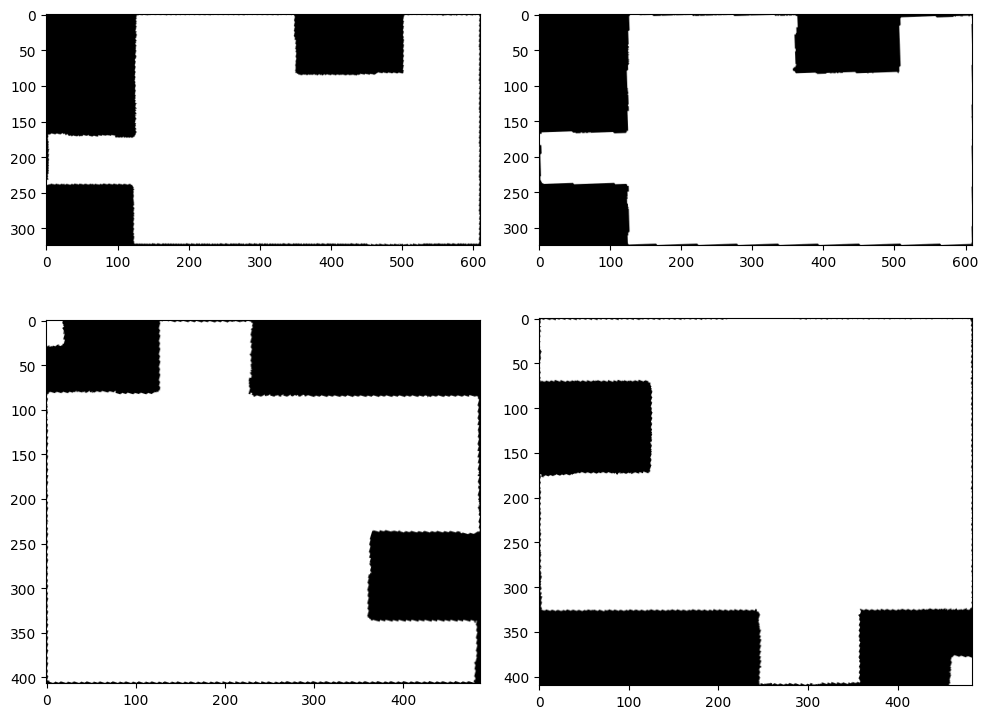

In [20]:
show_images(pieces, max_cols=2)

## Remove overlaps

Mask out the piece by largest white area. The small overlaps in the edges need to go.

In [21]:
masked_pieces = []

for p in pieces:
    contours, _ = cv2.findContours(p, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        masked_pieces.append(p)
        continue

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(p)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    result = cv2.bitwise_and(p, p, mask=mask)
    masked_pieces.append(result)

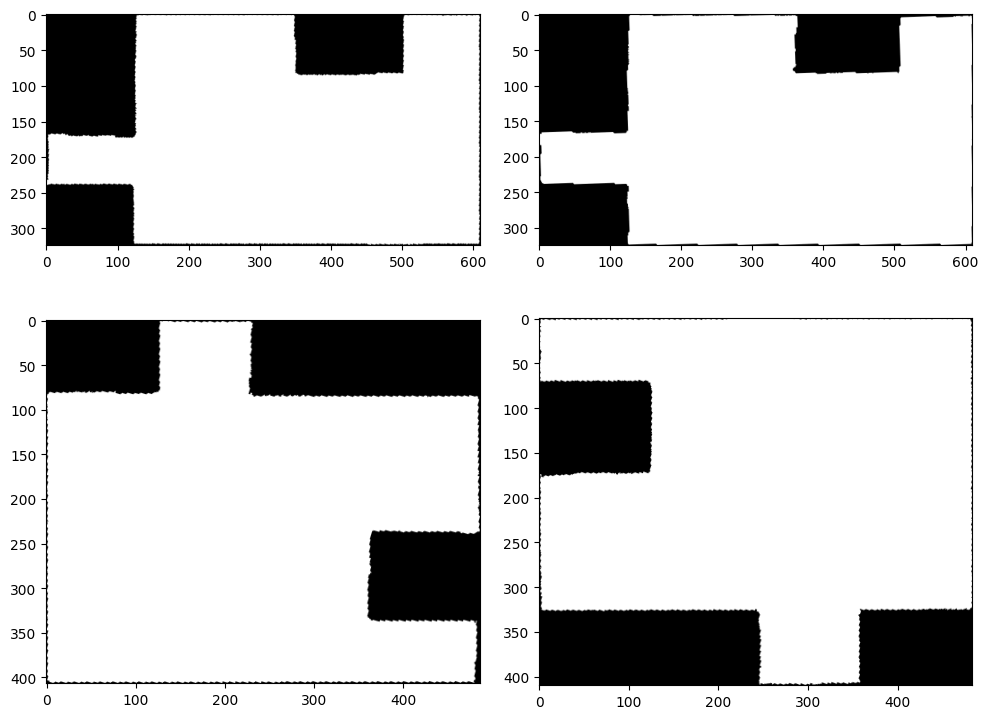

In [22]:
show_images(masked_pieces, max_cols=2)

## Smooth contours

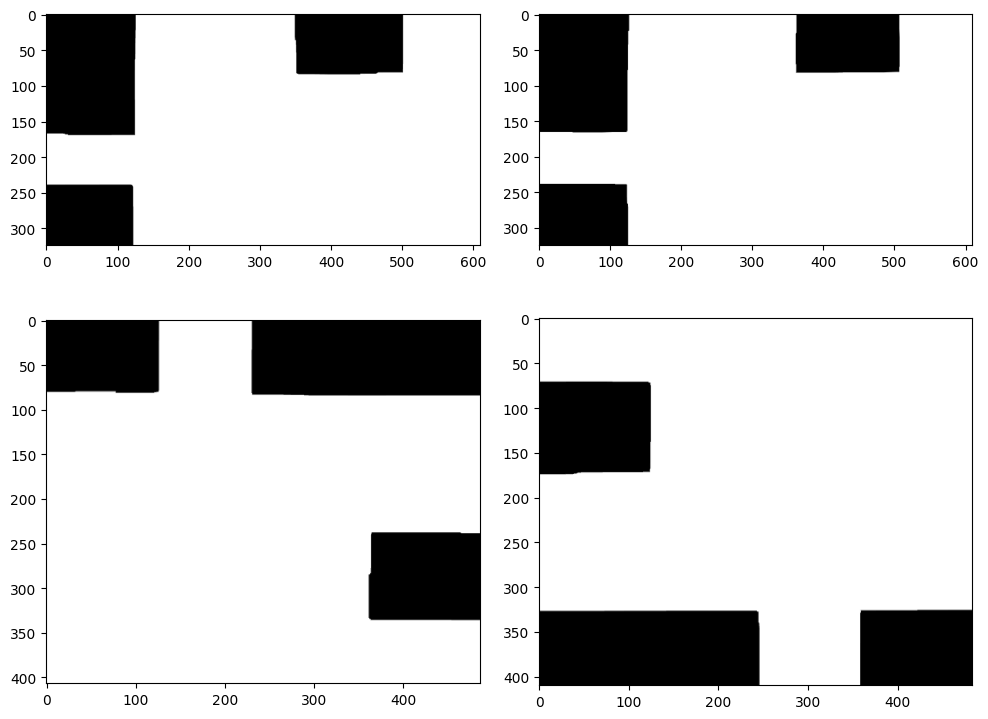

In [23]:
def smooth_mask(thresh, kernel_size=5, iterations=10):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    # Close small gaps, then open small noise
    smooth = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    smooth = cv2.morphologyEx(smooth, cv2.MORPH_OPEN, kernel, iterations=iterations)
    return smooth

smoothed_pieces = []

for p in masked_pieces:
    sp = smooth_mask(p)
    smoothed_pieces.append(sp)

show_images(smoothed_pieces, max_cols=2)

## Corner detection

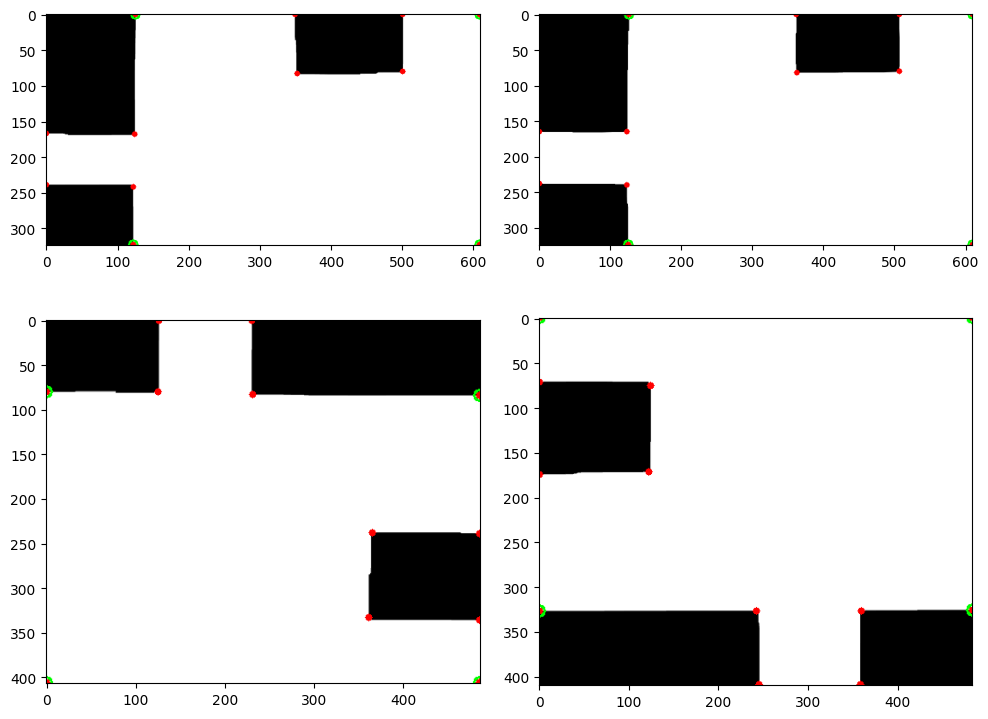

In [24]:
def extract_corners(piece_img, plot=True):
    # Convert to grayscale if needed
    gray = cv2.cvtColor(piece_img, cv2.COLOR_BGR2GRAY) if len(piece_img.shape) == 3 else piece_img.copy()

    # Find contour (largest one = main piece)
    contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour = max(contours, key=cv2.contourArea)

    # Smooth contour
    epsilon = 0.005 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # Compute curvature (corner strength)
    approx_pts = approx[:, 0, :]

    return approx_pts

def is_close_to_border_x(pt, img_shape, border_thresh=10):
    _, w = img_shape
    x, _ = pt
    return (x < border_thresh or x > w - border_thresh)

def is_close_to_border_y(pt, img_shape, border_thresh=10):
    h, _ = img_shape
    _, y = pt
    return (y < border_thresh or y > h - border_thresh)

def is_x_similar(pt1, pt2, thresh=10):
    return abs(pt1[0] - pt2[0]) < thresh

def is_y_similar(pt1, pt2, thresh=10):
    return abs(pt1[1] - pt2[1]) < thresh

def select_relevant_corners(corners, img_shape):
    selected = []
    close_to_corners = []
    close_to_edges = []

    for ept in corners:
        if is_close_to_border_y(ept, img_shape) and is_close_to_border_x(ept, img_shape):
            close_to_corners.append(ept)
        elif is_close_to_border_y(ept, img_shape) or is_close_to_border_x(ept, img_shape):
            close_to_edges.append(ept)

    if len(close_to_corners) == 4:
        return close_to_corners

    if len(close_to_corners) == 2:
        distances = []
        for (cpt, ept) in it.product(close_to_corners, close_to_edges):
            if is_x_similar(cpt, ept) or is_y_similar(cpt, ept):
                distances.append((np.linalg.norm(ept - cpt), ept))

        distances.sort(key=lambda x: x[0], reverse=True)

        return close_to_corners + [pt for _, pt in distances[:2]]

    return selected

pieces_corners = []

debug_images = []
for i, piece in enumerate(smoothed_pieces):
    corners = extract_corners(piece, plot=True)
    vis = cv2.cvtColor(piece, cv2.COLOR_GRAY2BGR)
    for pt in corners:
        cv2.circle(vis, tuple(pt), 4, (0, 0, 255), -1)
    selected = select_relevant_corners(corners, img_shape=piece.shape)
    pieces_corners.append((i, selected))
    for pt in selected:
        cv2.circle(vis, tuple(pt), 6, (0, 255, 0), 2)
    debug_images.append(vis)

show_images(debug_images, max_cols=2)

## Vectorize edges

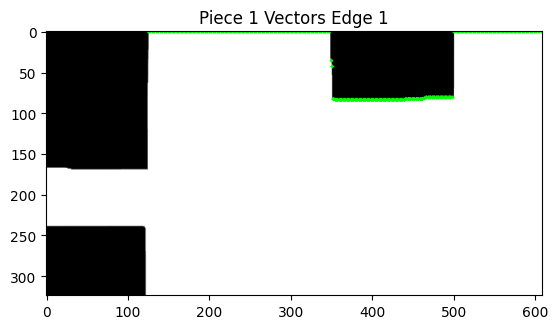

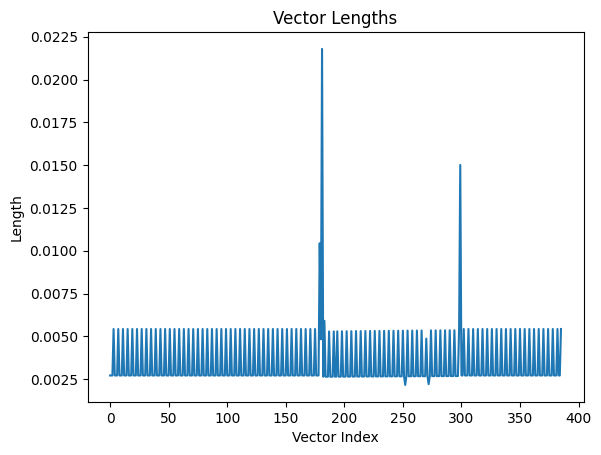

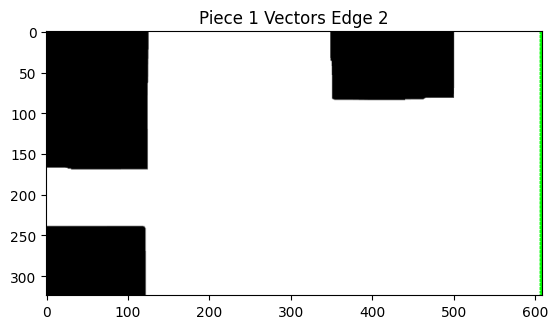

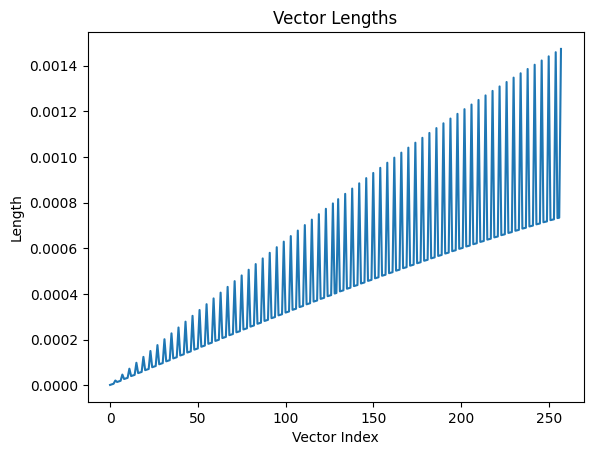

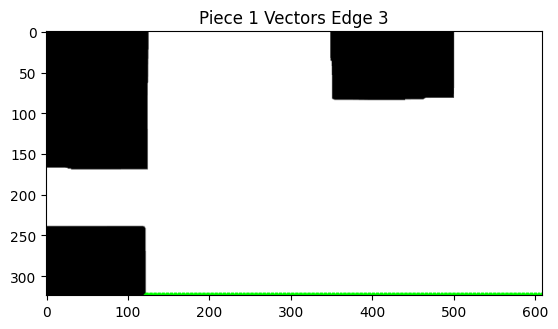

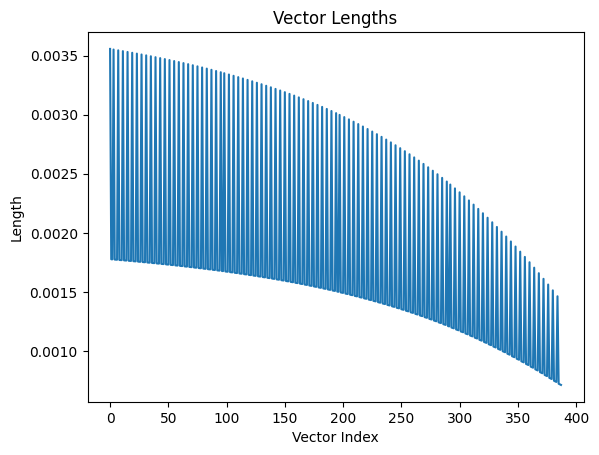

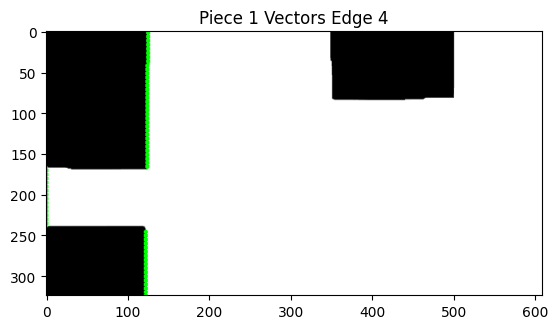

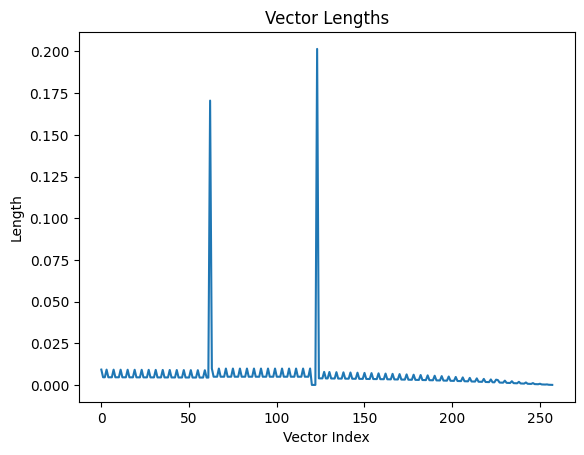

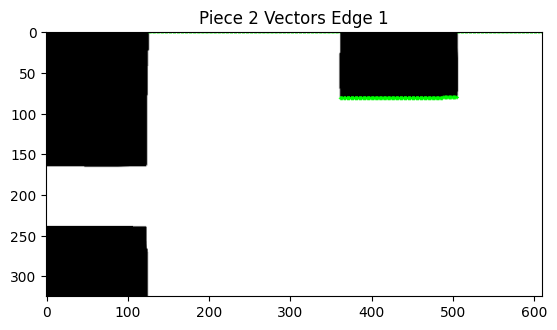

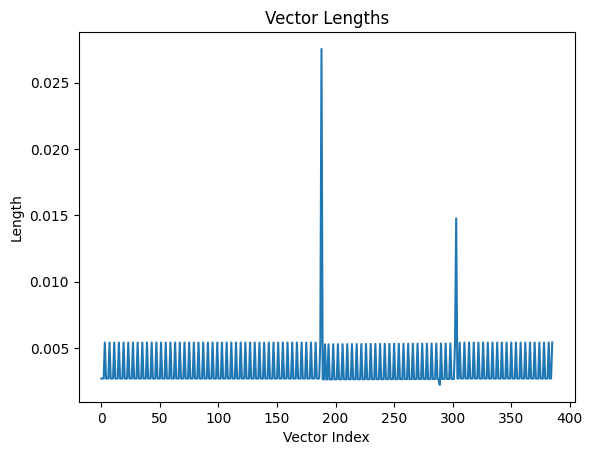

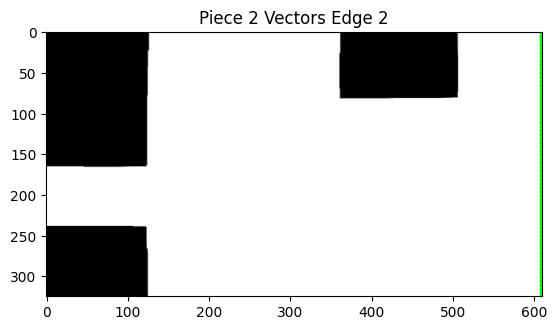

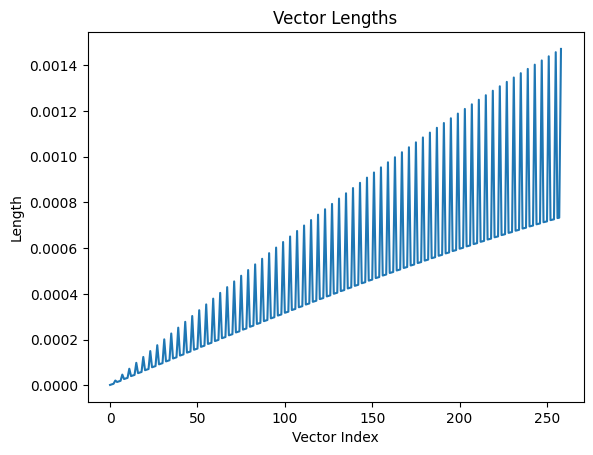

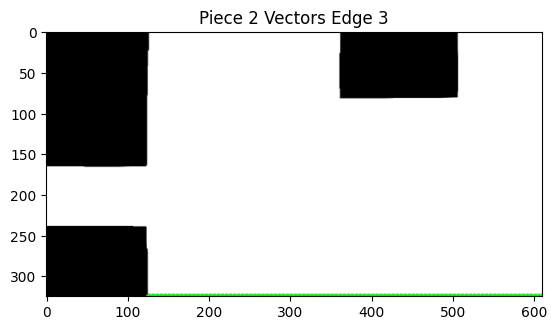

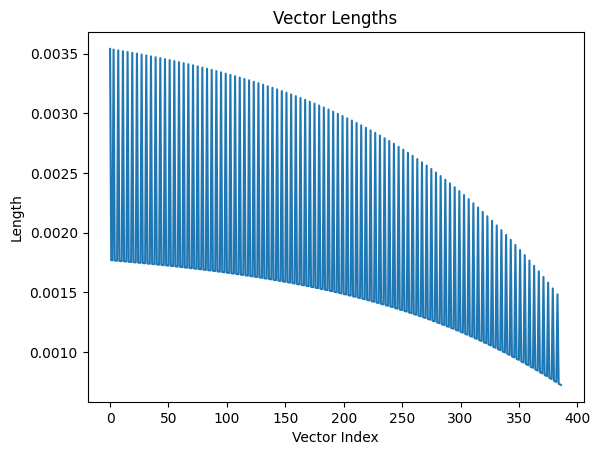

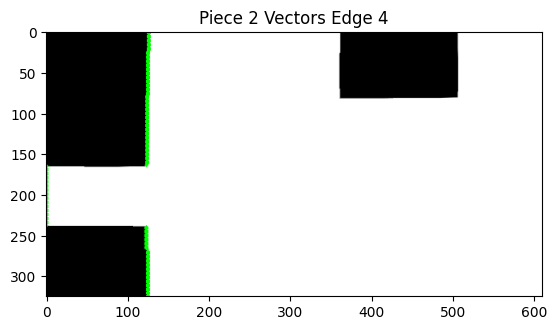

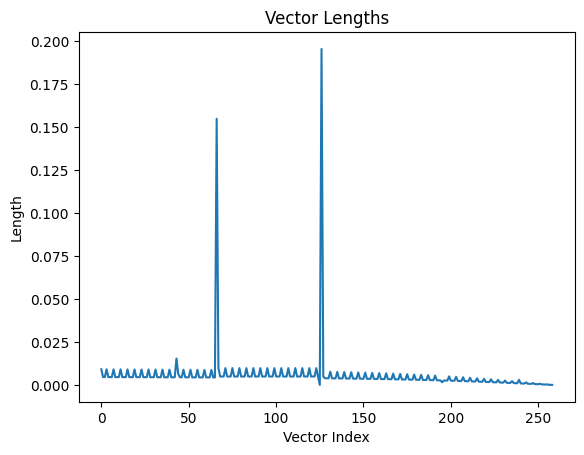

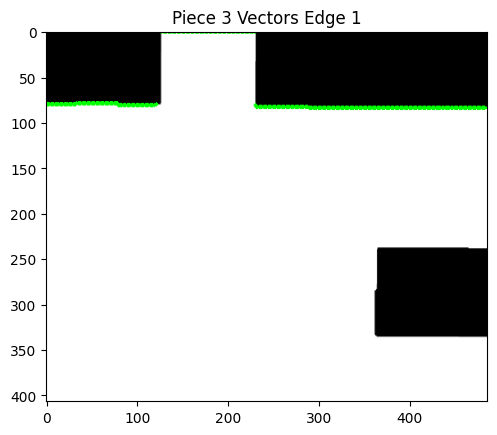

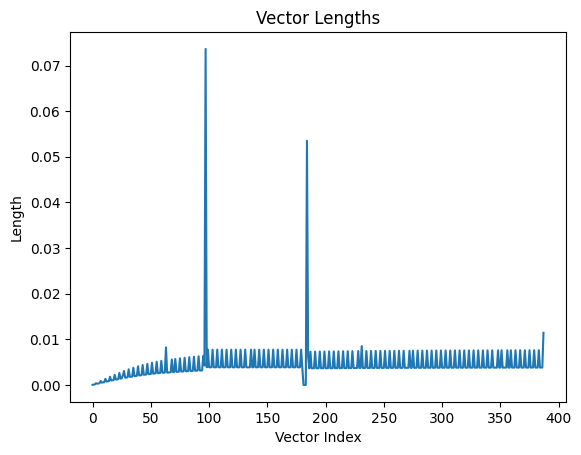

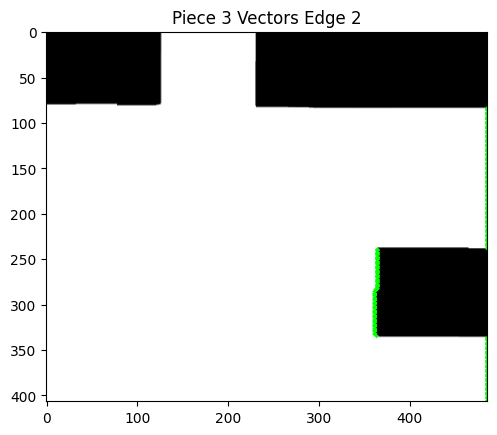

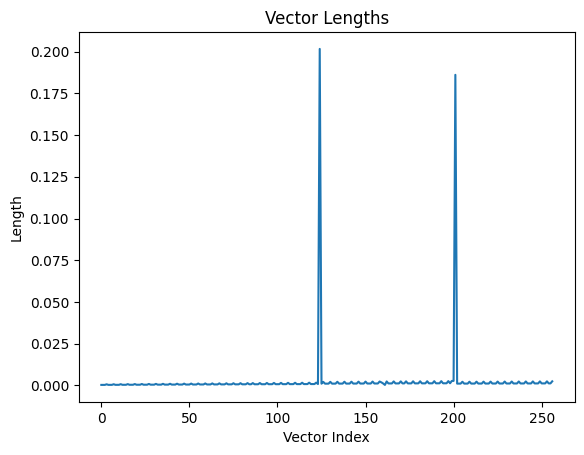

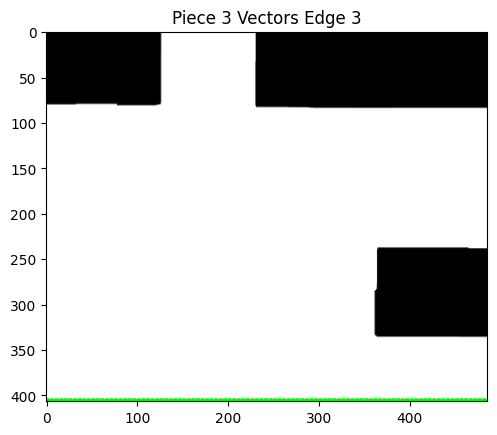

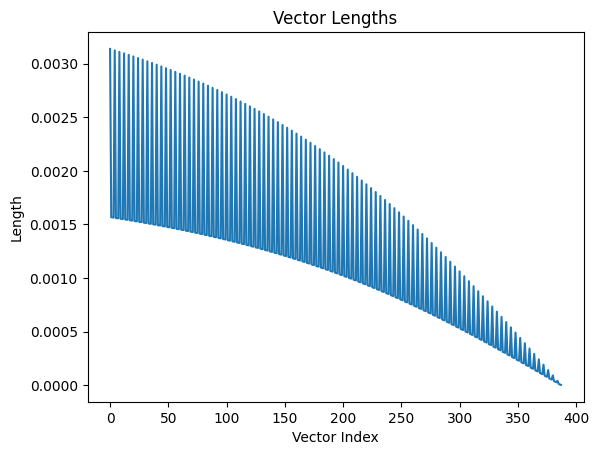

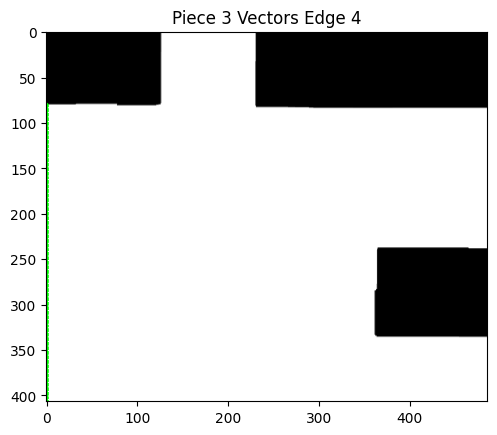

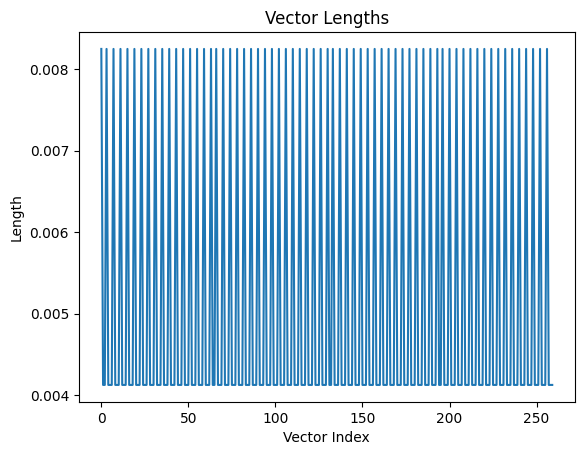

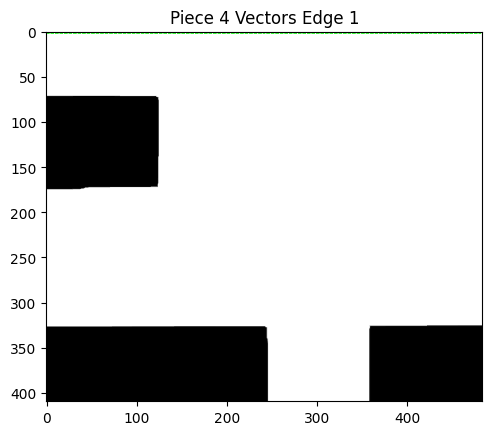

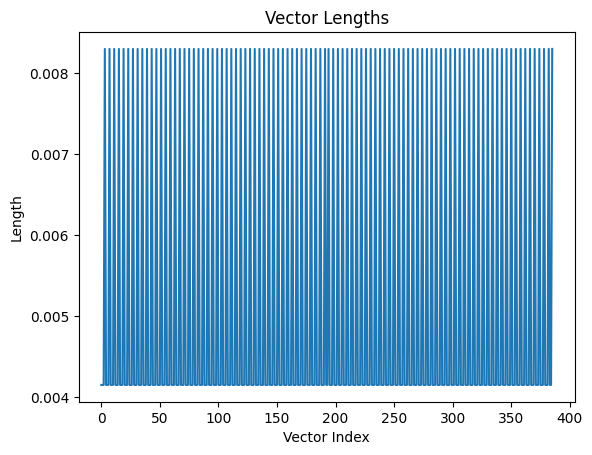

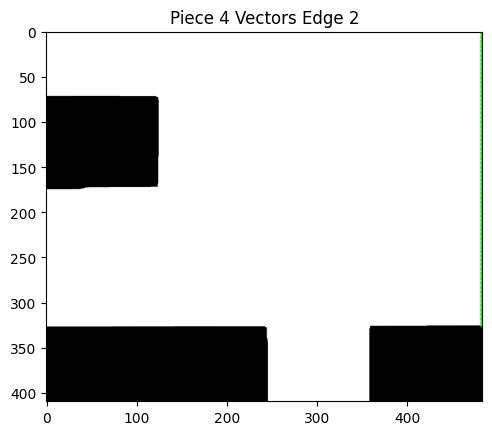

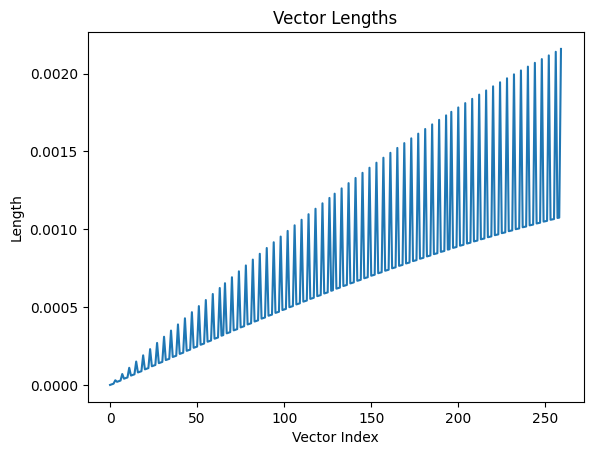

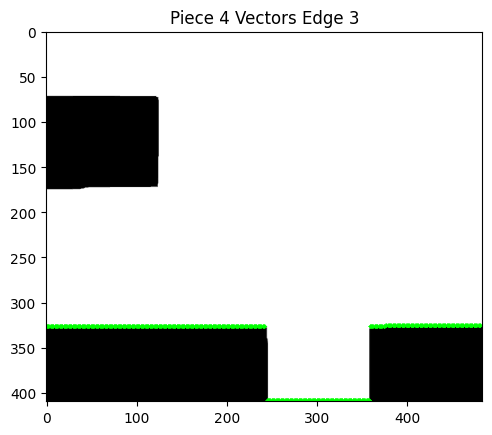

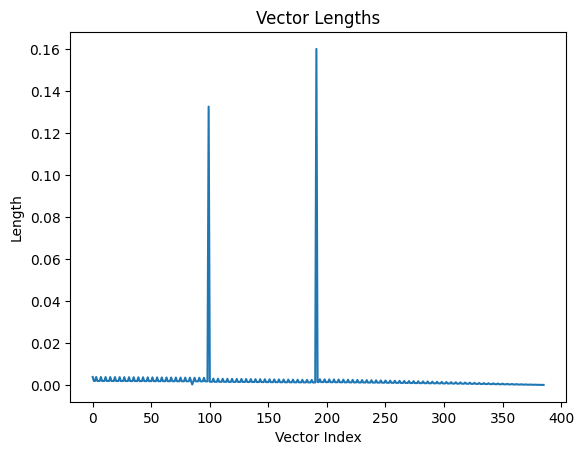

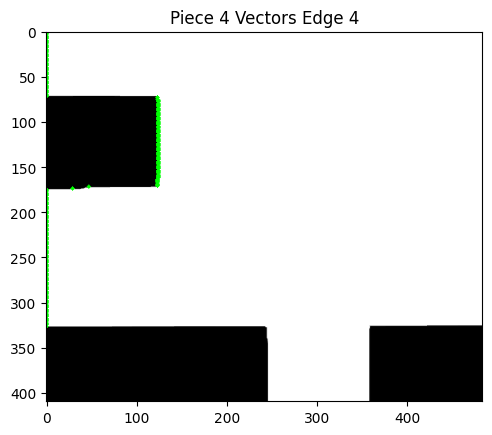

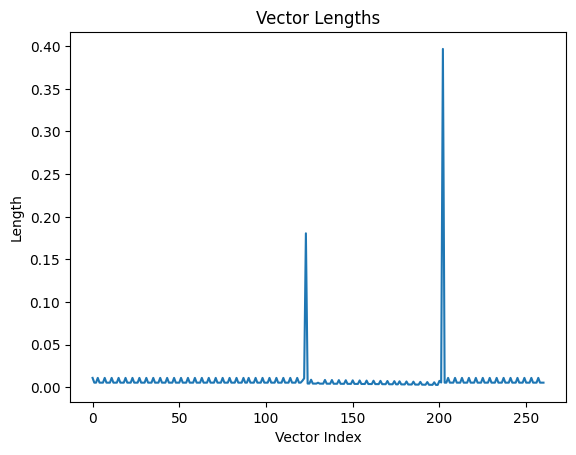

In [ ]:
def vectorize_edges(thresh, corners, n_vectors=-1):
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    h, w = thresh.shape

    # Sort in clockwise order
    corners = sorted(corners, key=lambda pt: math.atan2(pt[1] - h / 2, pt[0] - w / 2))

    # Calculate vectors between all adjacent corners
    # then sample along these edges to the countour of the piece
    edges_vectors = []
    for i in range(len(corners)):
        vectors = []
        pt1 = corners[i]
        pt2 = corners[(i + 1) % len(corners)]

        edge_vec = pt2 - pt1
        edge_length = np.linalg.norm(edge_vec)
        edge_dir = edge_vec / edge_length

        n_samples = n_vectors if n_vectors > 0 else int(edge_length * 0.8)
        for j in range(n_samples + 1):
            sample_pt = pt1 + edge_dir * (j * edge_length / n_samples)
            sample_pt = np.clip(sample_pt.astype(int), [0, 0], [w - 1, h - 1])

            # Move outward to find contour point
            normal_dir = np.array([-edge_dir[1], edge_dir[0]])
            for d in range(-500, 500):
                probe_pt = sample_pt + normal_dir * d
                probe_pt = np.clip(probe_pt.astype(int), [0, 0], [w - 1, h - 1])
                if mask[probe_pt[1], probe_pt[0]] == 255:
                    vectors.append(probe_pt)
                    break

        edges_vectors.append((i, vectors))

    return edges_vectors

def draw_vectors(image, vectors):
    image = np.copy(image)
    for pt in vectors:
        cv2.circle(image, tuple(pt), 2, (0, 255, 0), -1)
    return image

def plot_vector_lengths(vectors):
    lengths = []
    for i in range(1, len(vectors)):
        lengths.append(np.linalg.norm(vectors[i] - vectors[i - 1]))

    plt.plot(lengths)
    plt.title("Vector Lengths")
    plt.xlabel("Vector Index")
    plt.ylabel("Length")
    plt.show()

def normalize_vector_lengths(vectors):
    lengths = []
    for vec in vectors:
        lengths.append(np.linalg.norm(vec))

    mean_length = np.mean(lengths)
    normalized = []
    for l in lengths:
        if mean_length < 3:
            normalized.append(0)
        else:
            normalized.append(l / mean_length)

    return normalized

for (i, piece) in pieces_corners:
    thresh = smoothed_pieces[i]
    edges_vectors = vectorize_edges(thresh, piece)
    for edge_idx, vectors in edges_vectors:
        vis = draw_vectors(cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR), vectors)
        show_image(vis, f"Piece {i+1} Vectors Edge {edge_idx+1}")
        vector_lengths = normalize_vector_lengths(vectors)
        plot_vector_lengths(vector_lengths)

Piece #0


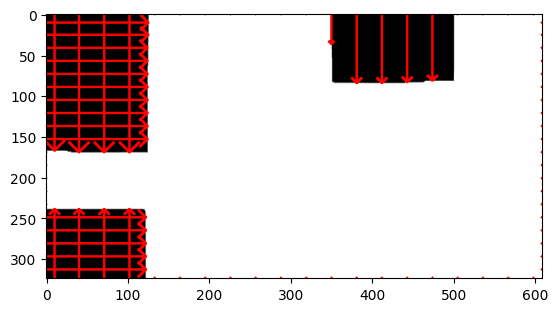

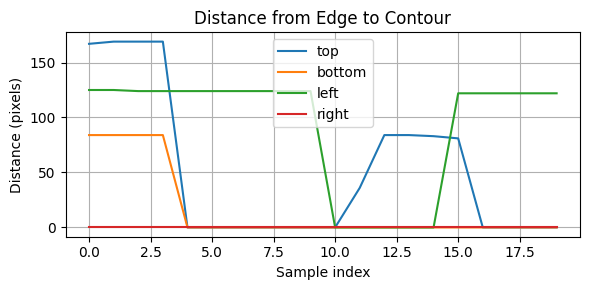

Piece #1


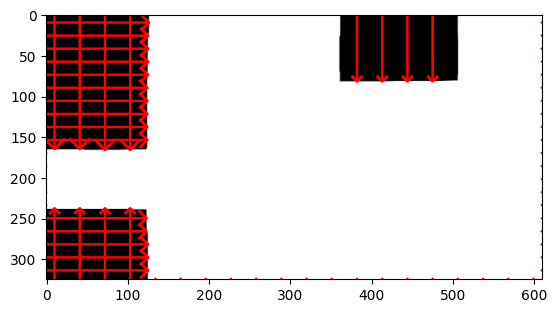

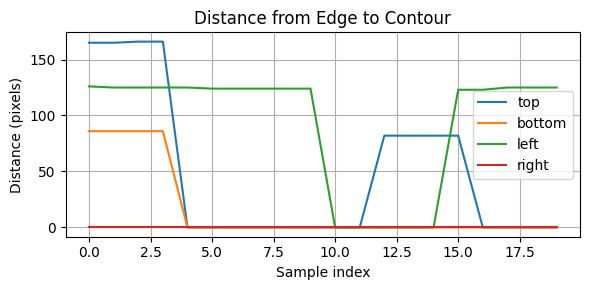

Piece #2


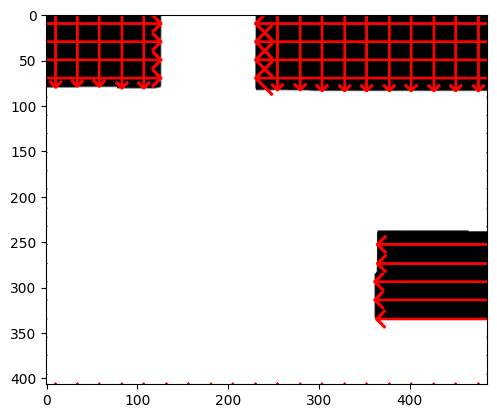

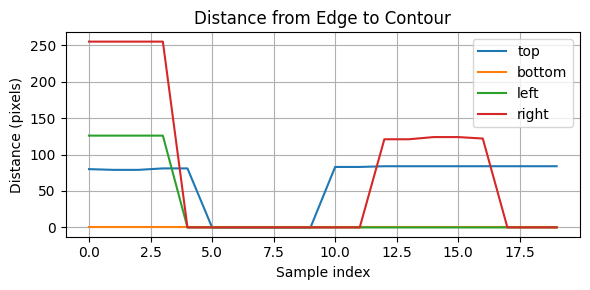

Piece #3


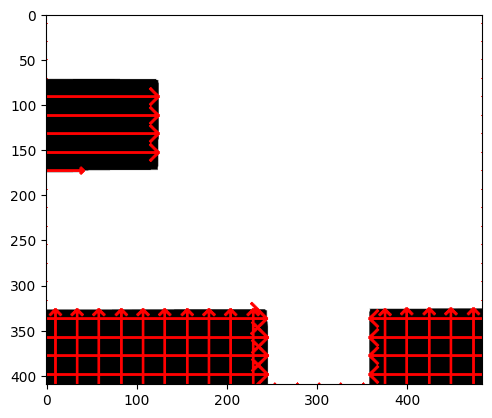

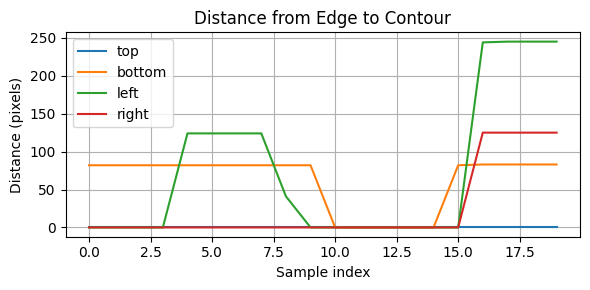

In [43]:
def measure_edge_distances(thresh, n_vectors=-1, margin=10):
    """Measure perpendicular distances from each image edge to the first contour pixel."""
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [contour], -1, 255, -1)

    h, w = thresh.shape

    if n_vectors == -1:
        x_samples = np.linspace(margin, w - 1 - margin, w, dtype=np.int32)
        y_samples = np.linspace(margin, h - 1 - margin, h, dtype=np.int32)
    else:
        x_samples = np.linspace(margin, w - 1 - margin, n_vectors, dtype=np.int32)
        y_samples = np.linspace(margin, h - 1 - margin, n_vectors, dtype=np.int32)

    distances = {
        "top": [],
        "bottom": [],
        "left": [],
        "right": []
    }

    # Measure top and bottom
    for x in x_samples:
        # Top
        for y in range(h):
            if mask[y, x] > 0:
                distances["top"].append(((x, 0), (x, y)))
                break

        # Bottom
        for y in range(h - 1, -1, -1):
            if mask[y, x] > 0:
                distances["bottom"].append(((x, h - 1), (x, y)))
                break

    # Measure left and right
    for y in y_samples:
        # Left
        for x in range(w):
            if mask[y, x] > 0:
                distances["left"].append(((0, y), (x, y)))
                break

        # Right
        for x in range(w - 1, -1, -1):
            if mask[y, x] > 0:
                distances["right"].append(((w - 1, y), (x, y)))
                break

    return distances


def draw_edge_vectors(thresh, distances, color=(0, 0, 255), thickness=2):
    """Draws precomputed edge vectors onto the thresholded image."""
    img_out = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)

    for edge_points in distances.values():
        for start, end in edge_points:
            cv2.arrowedLine(img_out, start, end, color, thickness, tipLength=0.1)

    return img_out

def plot_edge_distances(distances):
    """Plot distance (in pixels) from each edge to contour."""
    edge_names = ["top", "bottom", "left", "right"]

    plt.figure(figsize=(6, 3))
    for edge in edge_names:
        edge_points = distances.get(edge, [])
        if not edge_points:
            continue

        # Compute Euclidean distances
        dist_vals = [np.hypot(e[1][0] - e[0][0], e[1][1] - e[0][1]) for e in edge_points]
        plt.plot(dist_vals, label=edge)

    plt.title("Distance from Edge to Contour")
    plt.xlabel("Sample index")
    plt.ylabel("Distance (pixels)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for i, p in enumerate(smoothed_pieces):
    print(f"Piece #{i}")
    dist_info = measure_edge_distances(p, n_vectors=20, margin=10)
    vis = draw_edge_vectors(p, dist_info)
    show_image(vis)
    plot_edge_distances(dist_info)

Piece #0


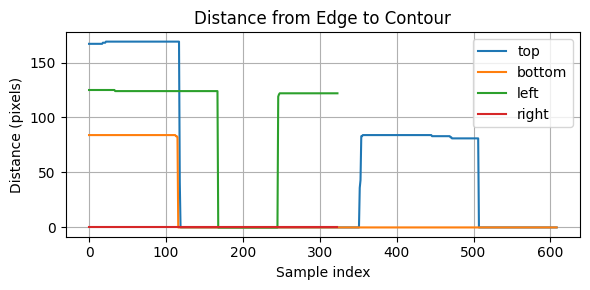

Piece #1


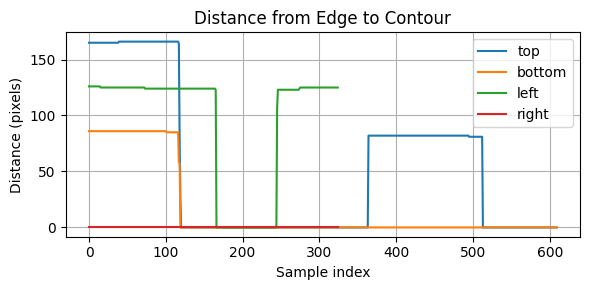

Piece #2


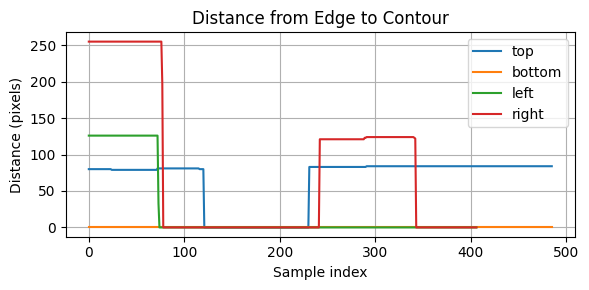

Piece #3


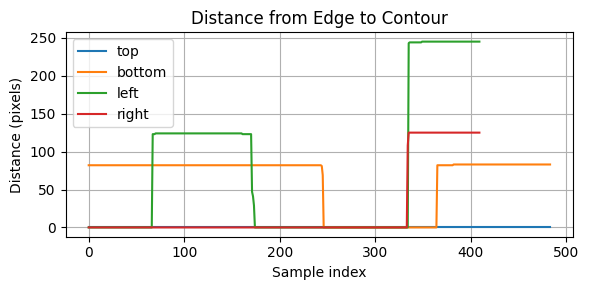

In [71]:
vectorized_pieces = {}

for i, p in enumerate(smoothed_pieces):
    dist = measure_edge_distances(p, margin=10)
    vectorized_pieces[i] = dist
    print(f"Piece #{i}")
    plot_edge_distances(dist)

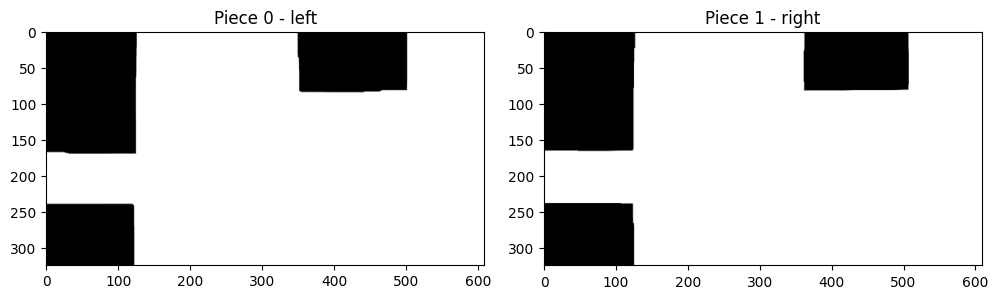

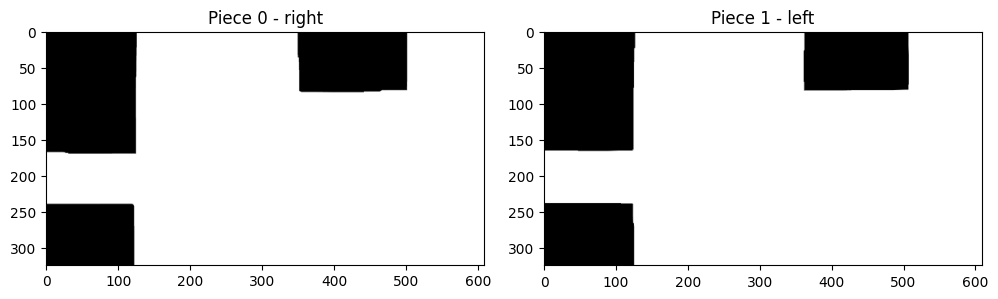

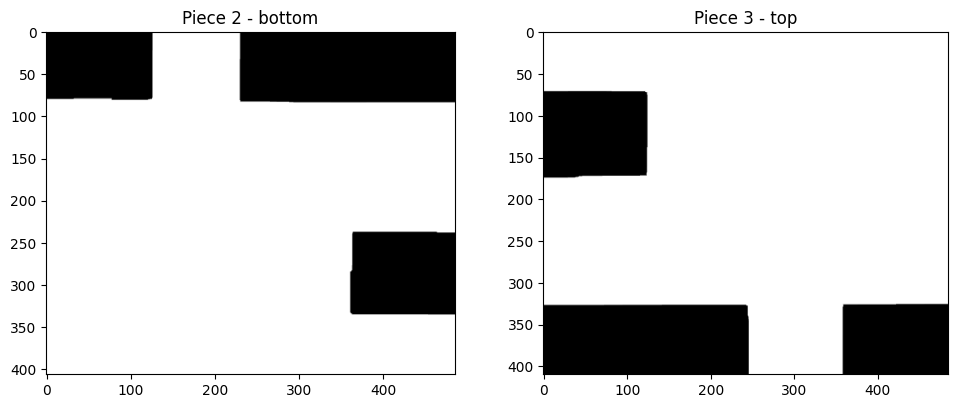

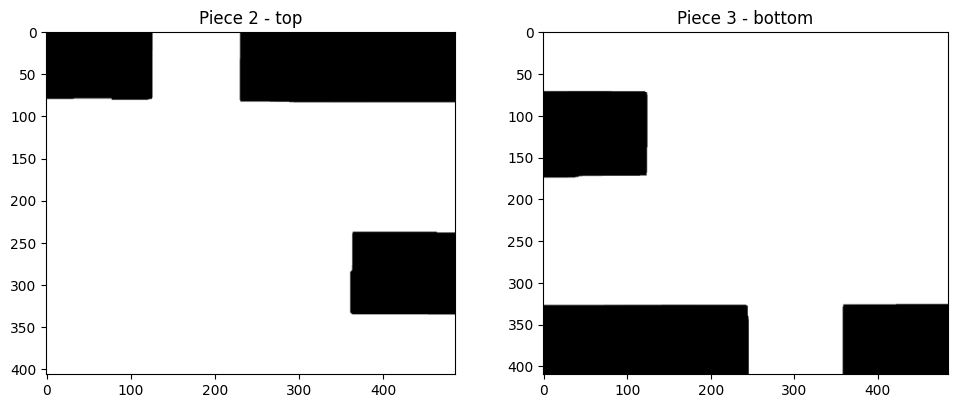

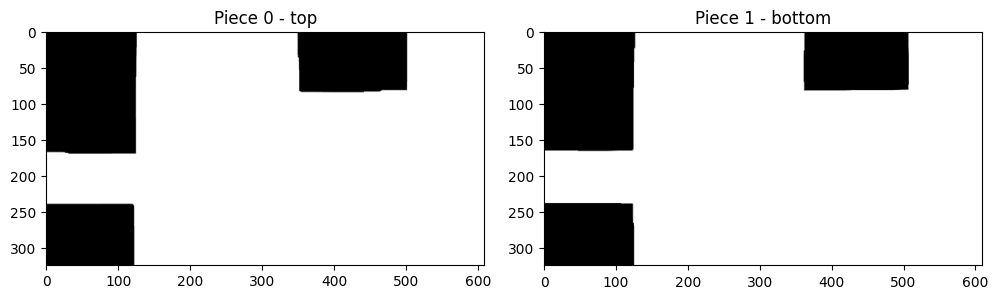

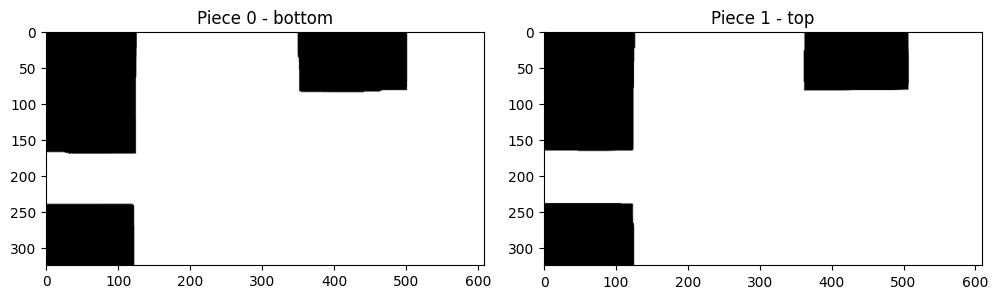

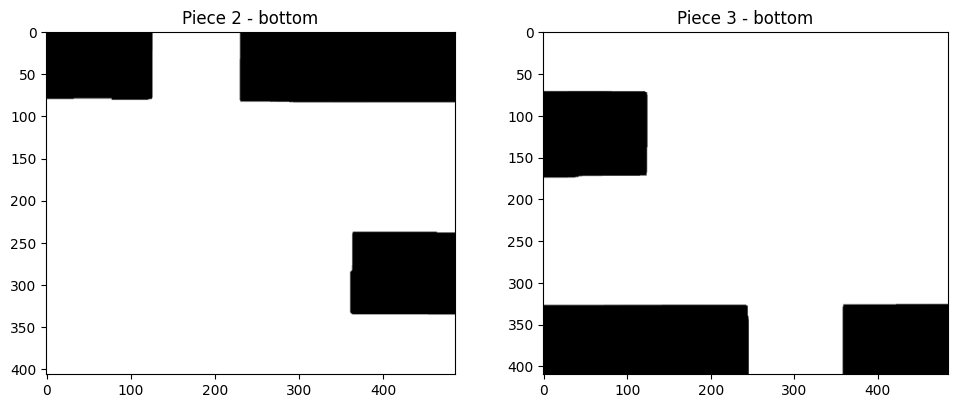

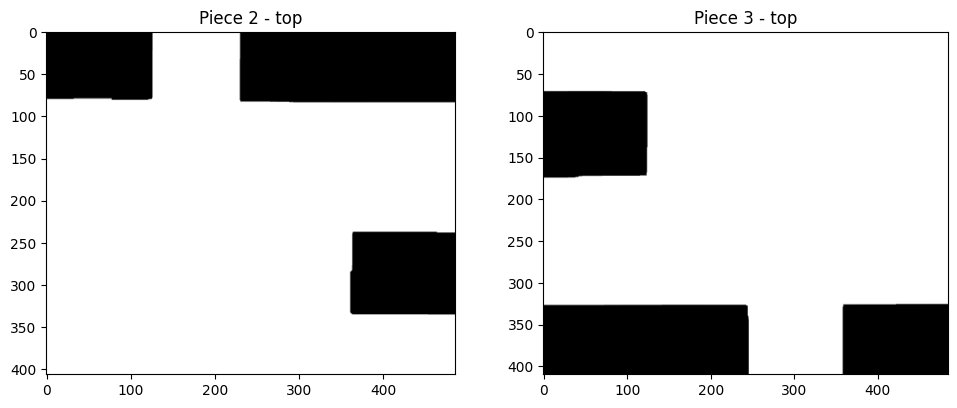

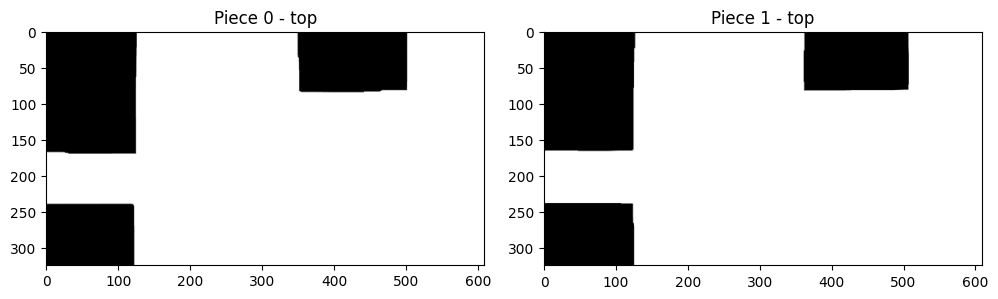

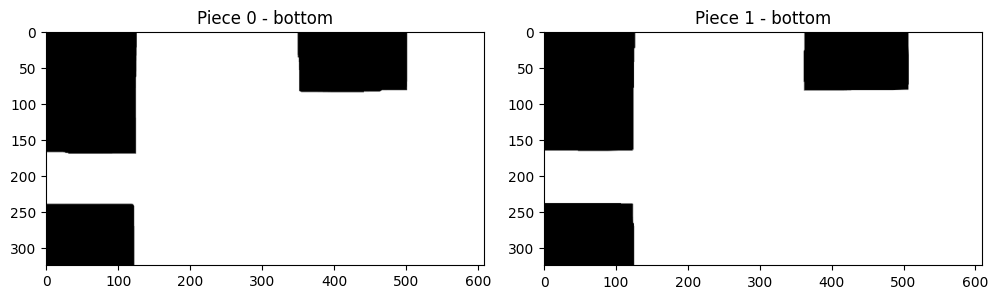

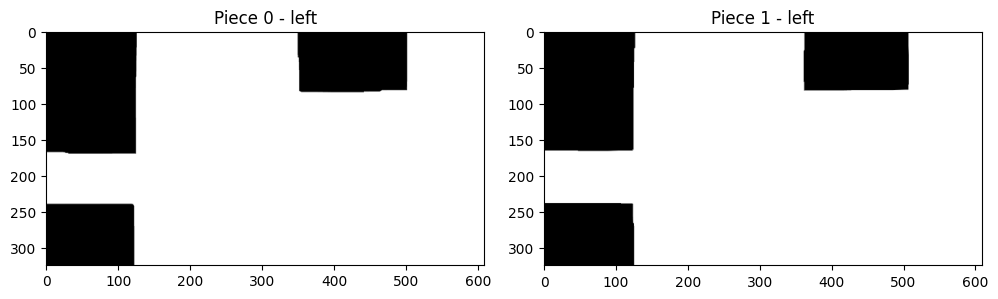

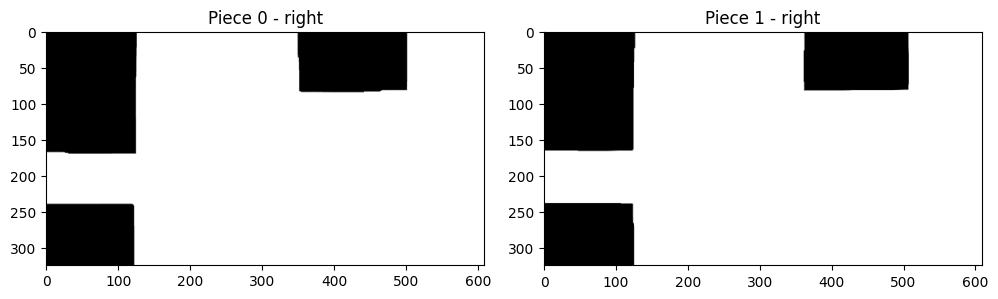

In [81]:
def convert_to_comparable_np_array(arr1, arr2):
    arr1 = np.array(arr1).flatten()
    arr2 = np.array(arr2).flatten()
    min_len = min(len(arr1), len(arr2))
    return arr1[:min_len], arr2[:min_len]

def normalize_vector(v):
    v = np.array(v, dtype=np.float32)
    v -= np.mean(v)
    std = np.std(v)
    if std > 1e-6:
        v /= std
    return v

def match_edges(vectorized_pieces, length_tolerance=10):
    """
    Match puzzle piece edges by complementary shape (inverted distance profiles).
    Returns dict: (piece1, edge1, piece2, edge2): compatibility_score
    Lower score = better fit.
    """
    matches = {}
    edges = ["top", "bottom", "left", "right"]

    for (p1_name, p1_edges), (p2_name, p2_edges) in it.combinations(vectorized_pieces.items(), 2):
        for p1_edge, p2_edge in it.product(edges, edges):
            arr1 = np.array(p1_edges[p1_edge]).flatten()
            arr2 = np.array(p2_edges[p2_edge]).flatten()

            # Skip if edge lengths differ too much
            if abs(len(arr1) - len(arr2)) > length_tolerance:
                continue

            # If majoirty of distances in an edge are near zero,
            # skip because it's likley a edge of a corner piece
            # This means it should not be matched with any other edge
            if (np.array(arr1) < 5).sum() / len(arr1) > 0.7:
                continue
            if (np.array(arr2) < 5).sum() / len(arr2) > 0.7:
                continue

            # Align and normalize
            arr1, arr2 = convert_to_comparable_np_array(arr1, arr2)
            arr1_norm = normalize_vector(arr1)
            arr2_norm = normalize_vector(arr2)

            # --- Invert arr2 for complementary matching ---
            arr2_inv = -arr2_norm

            # --- Compute cross-correlation between edge and inverted edge ---
            corr = correlate(arr1_norm, arr2_inv, mode="valid")
            corr_score = np.max(corr) / len(arr1_norm)

            # --- Euclidean difference (lower is better) ---
            eucl_dist = np.linalg.norm(arr1_norm + arr2_norm) / len(arr1_norm)

            # --- Combine into final "fit" score ---
            # High correlation (inverse match) & low Euclidean difference → strong fit
            fit_score = eucl_dist - corr_score  # you can tune weights

            matches[(p1_name, p1_edge, p2_name, p2_edge)] = fit_score

    return matches

matches = match_edges(vectorized_pieces)
sorted_matches = sorted(matches.items(), key=lambda x: x[1])

for ((p1, e1, p2, e2), _) in sorted_matches:
    show_images([smoothed_pieces[p1], smoothed_pieces[p2]], titles=[f"Piece {p1} - {e1}", f"Piece {p2} - {e2}"])

In [ ]:
def normalize_profile(profile):
    """Normalize distance profile to zero mean and unit variance."""
    p = np.array(profile, dtype=np.float32)
    p -= np.mean(p)
    p /= (np.std(p) + 1e-6)
    return p

def edge_similarity(edge1, edge2):
    """Compute similarity between two edges (higher = better match)."""
    e1 = normalize_profile(edge1)
    e2 = normalize_profile(edge2[::-1])  # reversed for complementary match
    # Use correlation as similarity metric
    return np.correlate(e1, e2, mode="valid")[0] / len(e1)

def match_pieces_by_edges(piece_distances):
    """
    piece_distances: dict of piece_id -> distance_dict (from measure_edge_distances)
    Returns list of (pieceA, edgeA, pieceB, edgeB, score)
    """
    matches = []
    pieces = list(piece_distances.keys())
    edges = ["top", "bottom", "left", "right"]

    for i, p1 in enumerate(pieces):
        for j, p2 in enumerate(pieces):
            if i >= j:
                continue  # avoid duplicate pairs

            for e1 in edges:
                for e2 in edges:
                    d1 = piece_distances[p1].get(e1, [])
                    d2 = piece_distances[p2].get(e2, [])
                    if not d1 or not d2:
                        continue

                    # Convert to distance magnitudes
                    prof1 = [np.hypot(e[1][0]-e[0][0], e[1][1]-e[0][1]) for e in d1]
                    prof2 = [np.hypot(e[1][0]-e[0][0], e[1][1]-e[0][1]) for e in d2]

                    # Match by correlation
                    score = edge_similarity(prof1, prof2)

                    matches.append((p1, e1, p2, e2, score))

    # Sort by best match (descending)
    matches.sort(key=lambda x: x[-1], reverse=True)
    return matches


matches = match_pieces_by_edges(vectorized_pieces)

# Show top matches
for m in matches[:10]:
    print(f"{m[0]}:{m[1]} ↔ {m[2]}:{m[3]}   score={m[4]:.3f}")

piece_2:left ↔ piece_3:right   score=0.987
piece_2:top ↔ piece_3:bottom   score=0.946
piece_2:right ↔ piece_3:left   score=0.927
piece_2:right ↔ piece_3:right   score=0.817
piece_2:left ↔ piece_3:left   score=0.817
piece_0:bottom ↔ piece_3:right   score=0.587
piece_1:bottom ↔ piece_3:right   score=0.579
piece_1:top ↔ piece_3:right   score=0.534
piece_1:left ↔ piece_2:right   score=0.529
piece_0:top ↔ piece_3:right   score=0.526


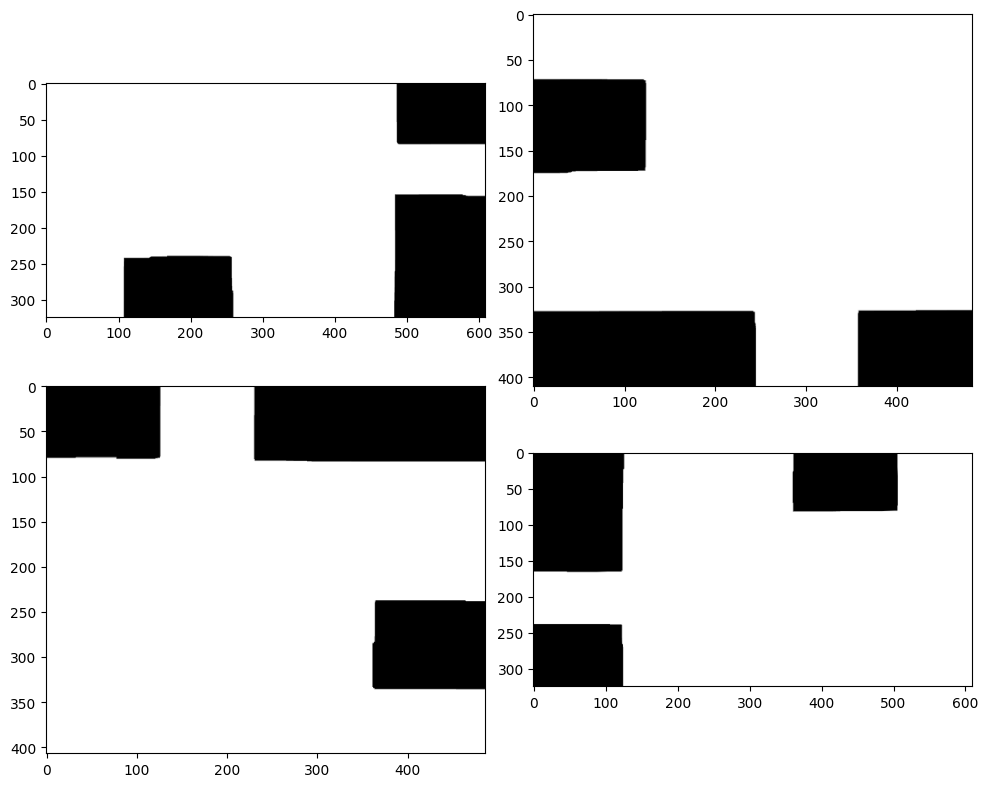

In [34]:
from PIL import Image
s = smoothed_pieces
show_images([np.array(Image.fromarray(s[0]).rotate(180)), s[3], s[2], s[1]], max_cols=2)

In [ ]:
EDGE_IDX = {"top": 0, "right": 1, "bottom": 2, "left": 3}
IDX_EDGE = {v: k for k, v in EDGE_IDX.items()}

def centroid_of_edge(dist_edge):
    """dist_edge: list of (start, end) pairs in local image coords.
       Return centroid of the end points (contour intersection points)."""
    ends = np.array([e[1] for e in dist_edge], dtype=np.float32)
    if len(ends) == 0:
        return np.array([0.0, 0.0], dtype=np.float32)
    return ends.mean(axis=0)

def rotate_image_and_points(img, points, angle_deg):
    """
    Rotate image around its center by angle_deg (positive = CCW).
    points: (N,2) coordinates relative to original image top-left.
    Returns: rotated_img, rotated_points (N,2), new_top_left_offset (x_shift, y_shift)
    new_top_left_offset is the translation from original image coordinate origin to new image origin.
    """
    h, w = img.shape[:2]
    cx, cy = w / 2.0, h / 2.0
    M = cv2.getRotationMatrix2D((cx, cy), angle_deg, 1.0)

    # compute new bounding dims
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # adjust translation in the transform
    M[0, 2] += (new_w / 2) - cx
    M[1, 2] += (new_h / 2) - cy

    # apply warp
    rotated = cv2.warpAffine(img, M, (new_w, new_h), flags=cv2.INTER_NEAREST, borderValue=(0,0,0))

    # transform points
    if len(points) > 0:
        ones = np.ones((points.shape[0], 1), dtype=np.float32)
        pts_h = np.hstack([points.astype(np.float32), ones])  # (N,3)
        rotated_pts = (M @ pts_h.T).T  # (N,2)
    else:
        rotated_pts = np.zeros((0,2), dtype=np.float32)

    # The offset from original top-left to new top-left is M applied to (0,0,1) minus (0,0)
    # But easier: if original origin maps to (tx, ty) in new image via M: tx = M[0,2], ty = M[1,2]
    offset = np.array([M[0,2], M[1,2]], dtype=np.float32)
    return rotated, rotated_pts, offset

def paste_with_mask(canvas, piece_img, piece_mask, top_left):
    """
    Paste piece_img onto canvas at top_left (x,y) using piece_mask (single channel, 255 inside).
    Returns canvas modified in place.
    """
    x, y = int(round(top_left[0])), int(round(top_left[1]))
    h, w = piece_img.shape[:2]
    H, W = canvas.shape[:2]

    x0 = max(0, x)
    y0 = max(0, y)
    x1 = min(W, x + w)
    y1 = min(H, y + h)

    if x1 <= x0 or y1 <= y0:
        return canvas  # completely outside

    # sub-regions
    px0 = x0 - x
    py0 = y0 - y
    px1 = px0 + (x1 - x0)
    py1 = py0 + (y1 - y0)

    roi_canvas = canvas[y0:y1, x0:x1]
    roi_piece = piece_img[py0:py1, px0:px1]
    roi_mask = piece_mask[py0:py1, px0:px1]

    # create 3-channel mask
    if len(roi_mask.shape) == 2:
        alpha = (roi_mask.astype(np.float32) / 255.0)[:,:,None]
    else:
        alpha = (cv2.cvtColor(roi_mask, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0)[:,:,None]

    # alpha blend (but because pieces are opaque, simple copy where mask==255)
    roi_canvas[:] = (roi_piece * alpha + roi_canvas * (1 - alpha)).astype(np.uint8)
    return canvas

def assemble_pieces_on_canvas(pieces_imgs, pieces_masks, piece_distances,
                              matches_sorted, canvas_size=(3000,3000), seed_piece_idx=0,
                              max_steps=100):
    """
    pieces_imgs: list of BGR images (masked pieces)
    pieces_masks: list of single-channel masks (255 inside piece)
    piece_distances: dict piece_id -> distances dict (as returned by measure_edge_distances)
    matches_sorted: list of tuples (pA_id, eA, pB_id, eB, score) sorted desc by score
    canvas_size: (W,H)
    seed_piece_idx: index of initial seed in pieces_imgs
    Returns: canvas image, placements dict (piece_id -> {top_left, rotation_deg, canvas_centroid})
    """

    # map piece_id strings to indices if needed
    # Accept both numeric indices or keys used in piece_distances (strings)
    # We'll use piece keys from piece_distances as canonical ids
    piece_ids = list(piece_distances.keys())
    id_to_idx = {pid: i for i, pid in enumerate(piece_ids)}

    # Prepare centroids for each piece and each edge (in local coords)
    edge_centroids = {}
    for pid in piece_ids:
        d = piece_distances[pid]
        edge_centroids[pid] = {}
        for edge in ["top","bottom","left","right"]:
            pts = d.get(edge, [])
            edge_centroids[pid][edge] = centroid_of_edge(pts)

    # Canvas and placement structures
    W, H = canvas_size
    canvas = np.zeros((H, W, 3), dtype=np.uint8)  # black background
    placements = {}  # pid -> dict(top_left, rotation_deg, centroid_abs)

    # helper to compute rotation needed for pB so that its edge eB faces opposite of pA:eA (considering pA rotation)
    def compute_rotation_for_alignment(pidA, eA, rotA_deg, pidB, eB):
        # global orientation indices
        eA_idx = EDGE_IDX[eA]
        eB_idx = EDGE_IDX[eB]
        eA_global = (eA_idx + int(round(rotA_deg / 90))) % 4
        # eB_global must be opposite
        desired_eB_global = (eA_global + 2) % 4
        # so rotB in 90-degree steps:
        rotB_steps = (desired_eB_global - eB_idx) % 4
        rotB_deg = int(rotB_steps * 90)
        return rotB_deg

    # Place seed in center
    seed_pid = piece_ids[seed_piece_idx]
    seed_img = pieces_imgs[id_to_idx[seed_pid]]
    seed_mask = pieces_masks[id_to_idx[seed_pid]]
    seed_h, seed_w = seed_img.shape[:2]
    seed_rotation = 0
    # compute centroid of whole piece mask (use moments)
    M = cv2.moments(seed_mask)
    if M["m00"] != 0:
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
    else:
        cx, cy = seed_w/2.0, seed_h/2.0
    # place so centroid at canvas center
    canvas_center = np.array([W/2.0, H/2.0], dtype=np.float32)
    top_left_seed = canvas_center - np.array([cx, cy], dtype=np.float32)

    paste_with_mask(canvas, seed_img, seed_mask, top_left_seed)
    placements[seed_pid] = {
        "top_left": top_left_seed,
        "rotation": seed_rotation,
        "centroid_abs": canvas_center
    }

    placed = set([seed_pid])
    unplaced = set(piece_ids) - placed

    steps = 0
    # We'll repeatedly try to find the best match where one piece is placed and the other not.
    while unplaced and steps < max_steps:
        steps += 1
        best_match = None
        best_score = -np.inf

        # find highest scoring match connecting placed <-> unplaced
        for (pA, eA, pB, eB, score) in matches_sorted:
            # ensure pA is placed and pB is unplaced OR vice versa
            if (pA in placed and pB in unplaced) or (pB in placed and pA in unplaced):
                if score > best_score:
                    best_score = score
                    best_match = (pA, eA, pB, eB, score)

        if best_match is None:
            break  # nothing left to attach

        pA, eA, pB, eB, score = best_match

        # which is placed?
        if pA in placed and pB in unplaced:
            placed_pid, placed_edge, unplaced_pid, unplaced_edge = pA, eA, pB, eB
        else:
            placed_pid, placed_edge, unplaced_pid, unplaced_edge = pB, eB, pA, eA

        # retrieve placement info
        placed_info = placements[placed_pid]
        placed_centroid_abs = np.array(placed_info["centroid_abs"], dtype=np.float32)
        rotA = placed_info["rotation"]

        # compute rotation for unplaced piece
        rotB = compute_rotation_for_alignment(placed_pid, placed_edge, rotA, unplaced_pid, unplaced_edge)

        # rotate unplaced image & mask and transform its edge centroid
        idxB = id_to_idx[unplaced_pid]
        imgB = pieces_imgs[idxB]
        maskB = pieces_masks[idxB]
        # original centroid for edge in local coords:
        edge_centroid_local = edge_centroids[unplaced_pid][unplaced_edge].reshape(1,2)

        rotated_imgB, rotated_edge_pts, offset = rotate_image_and_points(imgB, edge_centroid_local, rotB)
        rotated_maskB, _, _ = rotate_image_and_points(maskB, edge_centroid_local, rotB)[:3]  # rotates mask similarly

        rotated_edge_centroid = rotated_edge_pts[0]  # (x,y) relative to rotated image top-left

        # Now translate so rotated_edge_centroid lands on placed_centroid_abs
        top_left_B = placed_centroid_abs - rotated_edge_centroid

        # place the rotated piece
        paste_with_mask(canvas, rotated_imgB, rotated_maskB, top_left_B)

        # compute absolute centroid of piece (we can compute centroid of rotated mask)
        M2 = cv2.moments(rotated_maskB)
        if M2["m00"] != 0:
            cx2 = M2["m10"] / M2["m00"]
            cy2 = M2["m01"] / M2["m00"]
        else:
            cx2, cy2 = rotated_imgB.shape[1]/2.0, rotated_imgB.shape[0]/2.0
        centroid_abs_B = top_left_B + np.array([cx2, cy2], dtype=np.float32)

        placements[unplaced_pid] = {
            "top_left": top_left_B,
            "rotation": rotB,
            "centroid_abs": centroid_abs_B
        }

        placed.add(unplaced_pid)
        unplaced.remove(unplaced_pid)

    return canvas, placements

bgr_pieces = []
for img in masked_pieces:
    gray = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    mask = (gray > 0).astype(np.uint8) * 255
    bgr_pieces.append(mask)

canvas, placements = assemble_pieces_on_canvas(
    pieces_imgs=masked_pieces,
    pieces_masks=bgr_pieces,
    piece_distances=vectorized_pieces,
    matches_sorted=matches,
    canvas_size=(3000, 3000),
    seed_piece_idx=0  # start with first piece
)

show_image(canvas)

for pid, info in placements.items():
    print(f"{pid} placed at {info['top_left']} with rotation {info['rotation']}°")

error: OpenCV(4.11.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/moments.cpp:622: error: (-5:Bad argument) Invalid image type (must be single-channel) in function 'moments'


## Assemble pieces

Following cell not working...

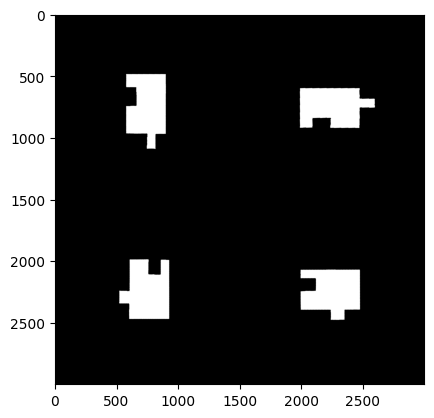

Piece 0 placed at [576.27039164 485.46054435] (rotation 90°)
Piece 1 placed at [1983.64775369  599.28260363] (rotation 180°)
Piece 2 placed at [ 520.35736603 1987.39284558] (rotation 90°)
Piece 3 placed at [1989.76566711 2070.85340262] (rotation 0°)


In [ ]:
def place_pieces_in_grid_with_rotation(pieces_imgs, pieces_masks, canvas_size=(3000, 3000)):
    """
    Places all pieces onto a canvas in a simple grid layout, with random 90-degree rotations.

    Args:
        pieces_imgs: List of BGR images.
        pieces_masks: List of single-channel masks.
        canvas_size: (W, H) of the output canvas.

    Returns:
        canvas image, placements dict (idx -> {top_left, rotation_deg, centroid_abs})
    """
    W, H = canvas_size
    canvas = np.zeros((H, W, 3), dtype=np.uint8)
    placements = {} # Use index as key for simplicity

    n_pieces = len(pieces_imgs)
    if n_pieces == 0:
        return canvas, placements

    grid_dim = int(np.ceil(np.sqrt(n_pieces)))
    if grid_dim == 0:
        return canvas, placements

    cell_w = W / grid_dim
    cell_h = H / grid_dim

    for i in range(n_pieces):
        img = pieces_imgs[i]
        mask = pieces_masks[i]

        # --- Random 90-degree rotation for each piece ---
        rotation_deg = np.random.choice([0, 90, 180, 270])

        # Rotate the image and mask
        # We need to rotate the mask to correctly calculate its centroid and dimensions
        rotated_img, _, _ = rotate_image_and_points(img, np.array([]), rotation_deg)
        rotated_mask, _, _ = rotate_image_and_points(mask, np.array([]), rotation_deg)

        h_rot, w_rot = rotated_img.shape[:2]

        # Find grid position (row, col)
        row = i // grid_dim
        col = i % grid_dim

        # Calculate center of the target cell
        cell_center_x = col * cell_w + cell_w / 2
        cell_center_y = row * cell_h + cell_h / 2

        # Find local centroid of the *rotated* piece mask to center it
        M_rot = cv2.moments(rotated_mask)
        if M_rot["m00"] != 0:
            cx_rot = M_rot["m10"] / M_rot["m00"]
            cy_rot = M_rot["m01"] / M_rot["m00"]
        else:
            cx_rot, cy_rot = w_rot / 2.0, h_rot / 2.0

        # Calculate top-left corner to center the rotated piece in its cell
        top_left = np.array([cell_center_x - cx_rot, cell_center_y - cy_rot])

        # Paste the rotated piece
        paste_with_mask(canvas, rotated_img, rotated_mask, top_left)

        # Calculate absolute centroid on the canvas
        centroid_abs = top_left + np.array([cx_rot, cy_rot], dtype=np.float32)

        placements[i] = {
            "top_left": top_left,
            "rotation": rotation_deg,
            "centroid_abs": centroid_abs
        }

    return canvas, placements

canvas_grid, placements_grid = place_pieces_in_grid_with_rotation(
    pieces_imgs=bgr_pieces,
    pieces_masks=masked_pieces,
    canvas_size=(3000, 3000)
)

# --- Your existing visualization code ---
show_image(canvas_grid)

for pid, info in placements_grid.items():
    print(f"Piece {pid} placed at {info['top_left']} (rotation {info['rotation']}°)")